# Circuit Simulation

## Imports

In [1]:
from pyimpspec import (
    ComplexImpedances,    # Alias for a NumPy array of complex128 values
    Frequencies,          # Alias for a NumPy array of float64 values
    Circuit,
    DataSet,
    FitResult,
    Element,              # The base class for all circuit elements
    ElementDefinition,    # A class that contains information regarding a new circuit element
    ParameterDefinition,  # A class that contains information regarding a circuit element's parameter
    register_element,     # A function that processes the new element class
    parse_cdc,
    fit_circuit,
    simulate_spectrum,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, BodePlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData, ResidualsData
from redoxed.impedance.drt_analysis import HN_Z, HN_DRT, SG_DRT, fit_DRT_peaks, find_DRT_peaks
from redoxed.dc import PolarisationData

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

## Simulation

{'L': 0.01}
{'C': 0.001}


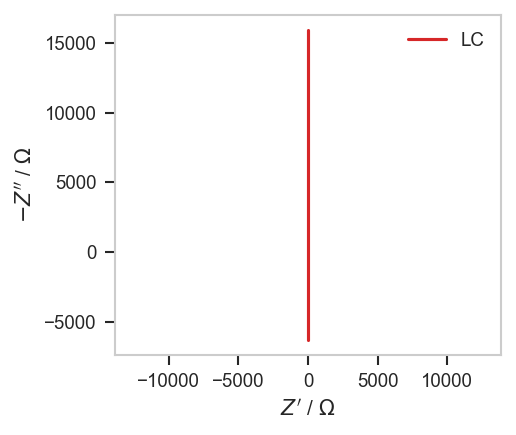

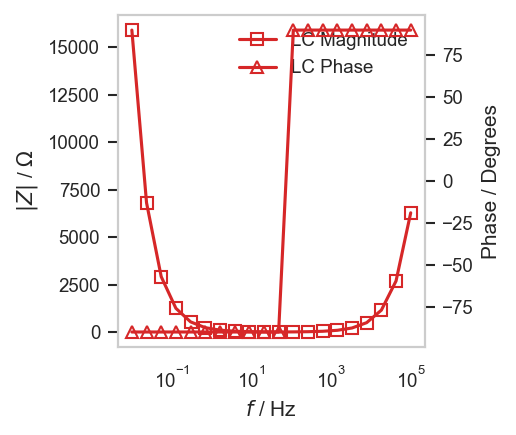

In [26]:


# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

############################
#### Circuit simulation ####
############################
frequencies = np.logspace(5, -2, num=20)  # Frequencies from 100 kHz to 10 mHz
circuit: Circuit = parse_cdc("[L{L=1e-2}C{C=1e-3}]")

# # circuit: Circuit = parse_cdc("[(L{L=1e-2}C{C=1e-3})]")

# circuit: Circuit = parse_cdc("[(R{R=-1e-1}L{L=1e-2}C{C=1e-3})]")

# # circuit: Circuit = parse_cdc("[(R{R=1e-1}L{L=1e-2})]")

# circuit: Circuit = parse_cdc("[R{R=1e-1}L{L=-1e-2}]")

data: DataSet = simulate_spectrum(circuit, frequencies=frequencies, label="LC")
EISData_circuit = EISData(Z = data.get_impedances(), f = data.get_frequencies(), label = data.get_label())
eis_plot_dict[EISData_circuit.label] = {
        "data": EISData_circuit,
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "-", "mfc": "none", "label": EISData_circuit.label},
        "plot": True
    }

# circuit: Circuit = parse_cdc("[LR(Q[RWs])]")
# circuit: Circuit = parse_cdc("[LaR]")
# circuit: Circuit = parse_cdc("[LR(Q[RWs])]")
# circuit: Circuit = parse_cdc("[LR{R=0.14}(Q[R{R=0.13}Ws])]")
# circuit: Circuit = parse_cdc("[LR{R=0.14}(Q[R{R=0.13}Ws{B=1,Y=17, n=0.5f}])]") # f fixes value of n, have really shown this to work out how to put limits on more complicated elements
# circuit: Circuit = parse_cdc("R{R=20f:sol}) # value of 20 fixed and label of sol
# circuit: Circuit = parse_cdc("R{R=20//1e2:sol}) # initial value of 20, no lower limit, 100 uppper limit, and label of sol



# Get all elements in the circuit
elements = circuit.get_elements()

# Extract parameters for each element
for elem in elements:
    print(elem.get_values())  # or elem.parameters, depending on implementation



## show results
# df: pd.DataFrame = fit.to_parameters_dataframe(running=True) # set true to start from 0
# parameters: str = df.to_markdown(index=False)
# parameters = df
# df = fit.to_statistics_dataframe()
# statistics: str = df.to_markdown(index=False)
# statistics = df
# display(Markdown(parameters))
# display(Markdown(statistics))
# display(parameters)
# display(statistics)
# ## simulate
# # data: DataSet = simulate_spectrum(fit.circuit, frequencies=np.logspace(3, 0, num=16), label="Randles")
# # fit.circuit.get_elements()[-1].get_values()
# ## show drawing
# drawing: Drawing = circuit.to_drawing(running=True, hide_labels = True)
# ## Useful other arguments
# # hide_labels: bool = False,
# # running: bool = False,
# # custom_labels: Optional[Dict[Element, str]] = None,
# # canvas: Optional[Union[str, "Axes"]] = None,  # noqa: F821
# display(drawing)
# #drawing.save(fname = "simple_circuit.svg", transparent = True, dpi = 72)

# #########################
# ### Circuit Residuals ###
# #########################

# observed = EISData_object
# predicted = EISData_circuit
# residuals_plot_dict[EISData_object.label] = {
#         "data": ResidualsData().calculate_residuals(observed = observed, predicted = predicted),
#         "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "mfc": "none", "label": EISData_object.label},
#         "plot": True
#     }

#########################
##### DRT fitting #######
#########################

# DRTData_object = DRTData(gamma=gamma, tau=tau)
# DRTData_object.label = "DRT exact"
# drt_plot_dict[DRTData_object.label] = {
#         "data": DRTData(gamma=gamma, tau=tau),
#         "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
#         "plot": True
#     }



#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
BodePlot_object = BodePlot(figsize=(3.543, 3), dpi = 150)

for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
        BodePlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
        #BodePlot_object.add_plot(entry["data"])#, **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
# NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

BodePlot_object.ax.legend()
BodePlot_object.fig.tight_layout() # try stop cutting off labels
display(BodePlot_object.fig)

# #########################
# #### Create DRT Plot ####
# #########################
# DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
# for label, entry in drt_plot_dict.items():
#     if entry["plot"]:
#         DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# DRTPlot_object.add_major_ticks(spacing_y = 1)
# # # DRTPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
# DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
# DRTPlot_object.fig.tight_layout() # try stop cutting off labels
# display(DRTPlot_object.fig)
# # DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

# ###########################
# ## Create Residuals Plot ##
# ###########################
# # ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'relative') # gets a bit misleading for small Z
# ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150, mode = 'absolute')
# for label, entry in residuals_plot_dict.items():
#     if entry["plot"]:
#         ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
# ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
# ResidualsPlot_object.ax.legend()
# display(ResidualsPlot_object.fig)